<a href="https://colab.research.google.com/github/JAMUNAASHREE18/jamunaa-codebooster1-2026/blob/main/Day2/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")
print(f"pandas vesion:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All libraries imported successfully!
pandas vesion:2.2.2
sqlite3 version:2.6.0


In [5]:
df=pd.read_csv('student_performance.csv')
print(f"Database loaded:{df.shape[0]}students.{df.shape[1]}columns")
print(f"columns:{df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)

Database loaded:30students.13columns
columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [8]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM STUDENTS")
count = cursor.fetchone()[0]
print(f"Database 'college.db' created successfully!")
print(f"Table 'students' has created Successfully!" )

Database 'college.db' created successfully!
Table 'students' has created Successfully!


In [15]:
def run_query(sql , description="student"):
  """
  runs a sql query and returns results as aa pandas dataframe

  parameter:
  ------
  sql : str - the sql  query string to execute
  description : str - a llabel to print above the results

  returns:
  pandas dataframe containing the query result
  """
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"\n{'='*55}")
  result = pd.read_sql_query(sql, conn)
  print(result.to_string(index= False))
  return result

print("function defined successfully")

function defined successfully


In [16]:
query1="""
    SELECT student_id , name , department , math_score , attendance_percentage
    FROM students
    LIMIT 10
"""
result1 = run_query(query1 , "Query 1: first 10 students (SELECT + LIMIT)")



Query 1: first 10 students (SELECT + LIMIT)

 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [27]:
query2 = """
     SELECT student_id , name FROM students LIMIT 5
"""

result2 = run_query(query2 , "Query 2: first 10 students (SELECT + LIMIT)")


Query 2: first 10 students (SELECT + LIMIT)

 student_id         name
       1001 Aarav Sharma
       1002  Priya Patel
       1003  Rohit Verma
       1004  Sneha Reddy
       1005   Arjun Nair


In [25]:
query3 = """
    SELECT  name , department , math_score FROM students WHERE math_score >= 90 ORDER BY math_score DESC LIMIT 5
"""
result3 = run_query(query3 , "Query 3: MATH SCORE (ORDER BY DESC + LIMIT)")


Query 3: MATH SCORE (ORDER BY DESC + LIMIT)

          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [28]:
query4 = """
    SELECT name, math_score, science_score, programming_score, attendance_percentage
    FROM students
    WHERE department = 'Computer Science'
    ORDER BY math_score DESC
"""
result4 = run_query(query4, "Query 4: MATH SCORE (ORDER BY DESC + LIMIT)")


Query 4: MATH SCORE (ORDER BY DESC + LIMIT)

          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
Swati Kulkarni          90             87                 92                     94
   Divya Singh          88             91                 93                     96
     Amit Bose          86             82                 89                     91
  Aarav Sharma          85             78                 91                     92
 Gaurav Shukla          84             79                 87                     87
    Suresh Rao          83             86                 88                     88
  Nisha Kapoor          79    

In [30]:
query4 = """
    SELECT  name , department , attendance_percentage FROM students WHERE department!='Civil' ORDER BY attendance_percentage DESC LIMIT 5
"""
result4 = run_query(query4 , "Query 4: High Attendance (>90%) Excluding Civil Dept")


Query 4: High Attendance (>90%) Excluding Civil Dept

          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95


In [32]:
query5 = """
    SELECT  name , department , attendance_percentage FROM students WHERE department!='Mechanical' ORDER BY attendance_percentage DESC LIMIT 5
"""
result5 = run_query(query5 , "Query 5: High Attendance (>93%) Excluding Mechanical Dept")


Query 5: High Attendance (>93%) Excluding Mechanical Dept

          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94


In [33]:
query6 = """
   SELECT name , department , attendance_percentage FROM students WHERE name BETWEEN 'A' AND 'F'
"""
result6 = run_query(query6, "Query 6: NAME BETWEEN A AND F (ORDER BY DESC + LIMIT)")


Query 6: NAME BETWEEN A AND F (ORDER BY DESC + LIMIT)

          name       department  attendance_percentage
  Aarav Sharma Computer Science                     92
    Arjun Nair Computer Science                     90
   Divya Singh Computer Science                     96
    Ananya Das Computer Science                     98
   Ajay Tiwari Computer Science                     75
Deepak Chauhan       Mechanical                     77
     Amit Bose Computer Science                     91
Akanksha Yadav Computer Science                     95


In [37]:
query7="""
SELECT department,
COUNT(*) AS num_student,
ROUND(AVG(math_score),2) AS avg_math_score,
ROUND(AVG(science_score),2) AS avg_science_score,
ROUND(AVG(programming_score),2) AS avg_programming_score,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
result7=run_query(query7,"Query 7: Department-wise Average score(GROUP BY)")


Query 7: Department-wise Average score(GROUP BY)

      department  num_student  avg_math_score  avg_science_score  avg_programming_score  avg_attendance
Computer Science           13           85.62              84.46                  89.23           90.69
      Mechanical            6           71.00              76.50                  49.33           83.50
     Electronics            6           71.00              74.17                  61.50           80.33
           Civil            5           63.40              66.60                  40.60           74.60


In [43]:
query8 = """
    SELECT
         department,
         COUNT(*)  AS num_students,
         ROUND(AVG(math_score) , 2) AS avg_maths

    FROM students

    GROUP BY department
    HAVING avg_maths > 70
    ORDER BY avg_maths DESC
"""
result8 = run_query(query8, "Query 8: (HAVING)")


Query 8: (HAVING)

      department  num_students  avg_maths
Computer Science            13      85.62
      Mechanical             6      71.00
     Electronics             6      71.00


In [51]:
query9 = """
    SELECT
         gender,
         COUNT(*)  AS num_students,
         ROUND(AVG(math_score) , 2) AS avg_maths,
         ROUND(AVG(programming_score) , 2) AS  avg_program,
         ROUND(AVG(attendance_percentage) , 2) AS  avg_attendance

    FROM students

    GROUP BY gender
    ORDER BY avg_maths DESC
"""
result9 = run_query(query9, "Query 9: gender wise  (GROUP BY)")


Query 9: gender wise  (GROUP BY)

gender  num_students  avg_maths  avg_program  avg_attendance
Female            15      78.47         70.2           88.53
  Male            15      73.67         65.0           80.47


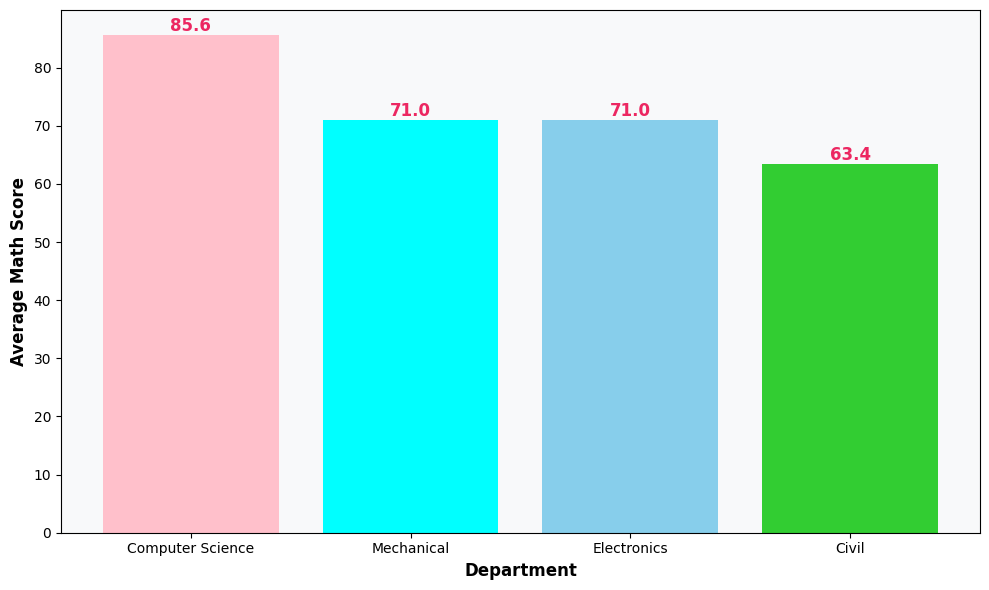

In [56]:
chart1_sql = """
    SELECT department, ROUND(AVG(math_score), 2) AS avg_maths
    FROM students
    GROUP BY department
    ORDER BY avg_maths DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#FFC0CB', '#00FFFF', '#87CEEB', '#32CD32']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_maths'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.0
)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.0,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='#EC2761'
    )

# X-axis label
ax.set_xlabel(
    'Department',
    fontsize=12,
    fontweight='bold'
)

# Y-axis label
ax.set_ylabel(
    'Average Math Score',
    fontsize=12,
    fontweight='bold'
)

# Background color
ax.set_facecolor('#F8F9FA')

# Remove grid lines
ax.grid(False)

# Rotate x labels slightly
plt.xticks(rotation=0)

# Adjust layout
plt.tight_layout()

# Show chart
plt.show()

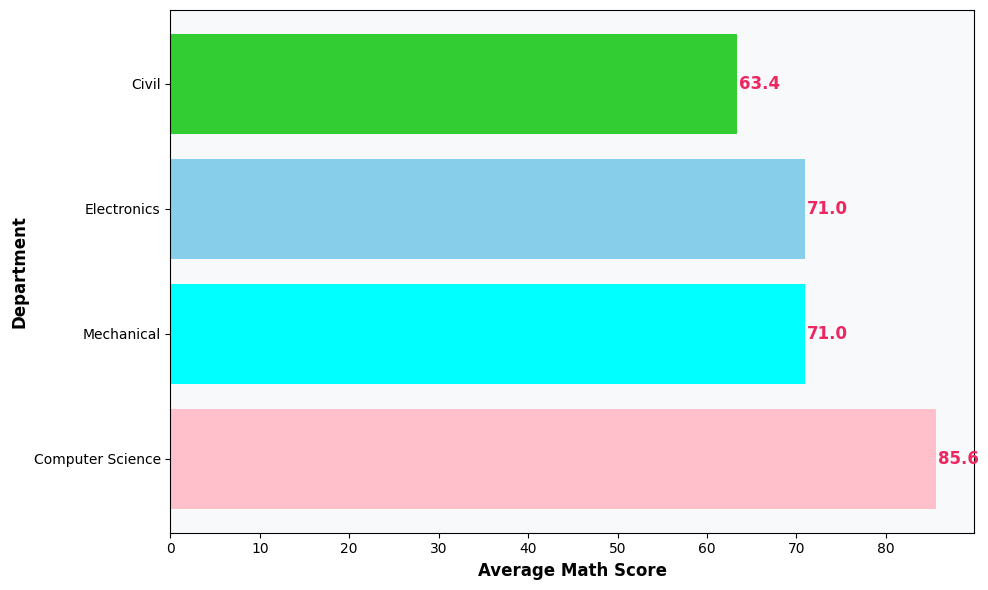

In [57]:
chart1_sql = """
    SELECT department, ROUND(AVG(math_score), 2) AS avg_maths
    FROM students
    GROUP BY department
    ORDER BY avg_maths DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#FFC0CB', '#00FFFF', '#87CEEB', '#32CD32']

# Horizontal bar chart (axis changed)
bars = ax.barh(
    chart1_data['department'],
    chart1_data['avg_maths'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.0
)

# Add value labels
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}',
        ha='left',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='#EC2761'
    )

# X-axis label
ax.set_xlabel(
    'Average Math Score',
    fontsize=12,
    fontweight='bold'
)

# Y-axis label
ax.set_ylabel(
    'Department',
    fontsize=12,
    fontweight='bold'
)

# Background color
ax.set_facecolor('#F8F9FA')

# Remove grid lines
ax.grid(False)

# Adjust layout
plt.tight_layout()

# Show chart
plt.show()

all libraries imported
pandas version: 2.2.2
sql version: 2.6.0


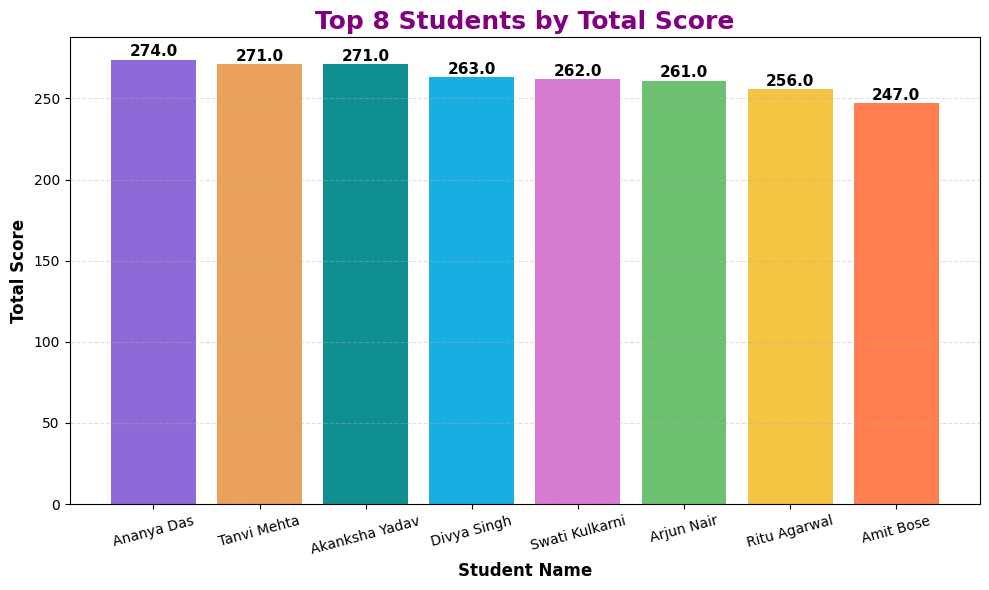

In [61]:
# step-1 importing the libraries
# pandas is to fetch the data from the dataset
# matplotlib.pyplot visualization

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')  # ignores the warnings

print("all libraries imported")
print(f"pandas version: {pd.__version__}")
print(f"sql version: {sqlite3.version}")

df = pd.read_csv('student_performance.csv')

conn = sqlite3.connect('college.db')
cursor = conn.cursor()

df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

cursor.execute("SELECT COUNT(*) FROM STUDENTS")
count = cursor.fetchone()[0]

# Query to get Top 8 students based on total score
chart2_sql = """
    SELECT name,
           (math_score + science_score + english_score) AS total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 8
"""

chart2_data = pd.read_sql_query(chart2_sql, conn)

# Plot
plt.figure(figsize=(10, 6))

# Changed axis using vertical bar chart
bars = plt.bar(
    chart2_data['name'],
    chart2_data['total_score'],
    color=[
        '#8e6ad8', '#e9a15b', '#0f8f8f', '#19aee2',
        '#d67ad2', '#6cc070', '#f4c542', '#ff7f50'
    ]
)

# Title and labels
plt.title(
    "Top 8 Students by Total Score",
    fontsize=18,
    fontweight='bold',
    color='purple'
)

plt.xlabel(
    "Student Name",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Total Score",
    fontsize=12,
    fontweight='bold'
)

# Add score labels on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f'{height:.1f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Optional: Rotate student names
plt.xticks(rotation=15)

# Style
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

# Show chart
plt.show()

all libraries imported
pandas version: 2.2.2
sql version: 2.6.0


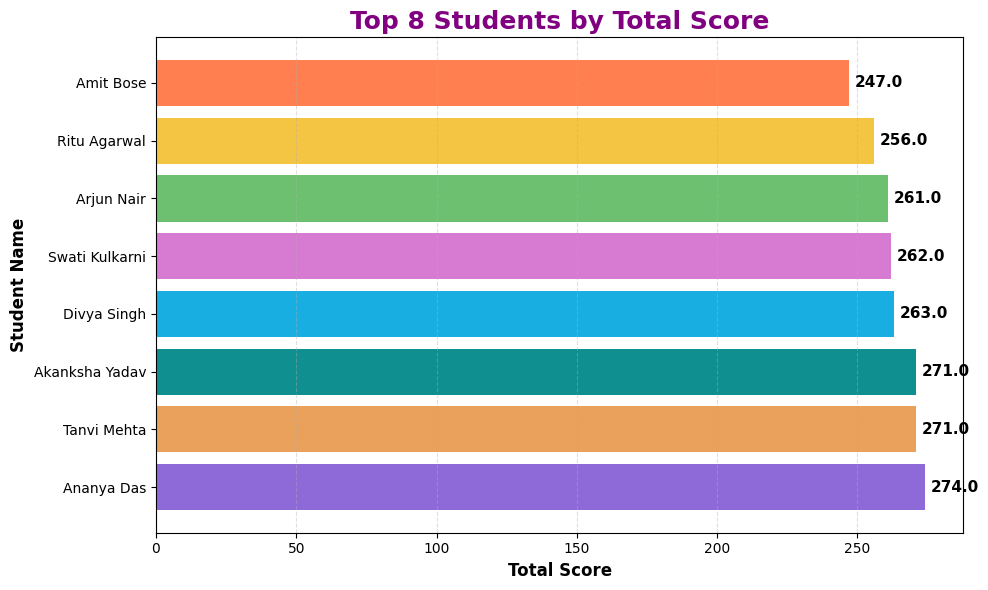

In [62]:
#step-1 importing the libraries
#pandas is to fetch the data  from the dataset
#matplotlib.pyplot visualization
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')#ignores the warnings

print("all libraries imported")
print(f"pandas version: {pd.__version__}")
print(f"sql version: {sqlite3.version}")

df = pd.read_csv('student_performance.csv')


conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM STUDENTS")
count = cursor.fetchone()[0]

# Query to get Top 8 students based on total score
chart2_sql = """
    SELECT name,
           (math_score + science_score + english_score) AS total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 8
"""

chart2_data = pd.read_sql_query(chart2_sql, conn)

# Plot
plt.figure(figsize=(10, 6))

bars = plt.barh(
    chart2_data['name'],
    chart2_data['total_score'],
    color=['#8e6ad8', '#e9a15b', '#0f8f8f', '#19aee2',
           '#d67ad2', '#6cc070', '#f4c542', '#ff7f50']
)

# Title and labels
plt.title("Top 8 Students by Total Score",
          fontsize=18,
          fontweight='bold',
          color='purple')

plt.xlabel("Total Score", fontsize=12, fontweight='bold')
plt.ylabel("Student Name", fontsize=12, fontweight='bold')

# Add score labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2,
             bar.get_y() + bar.get_height()/2,
             f'{width:.1f}',
             va='center',
             fontsize=11,
             fontweight='bold')

# Style
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [58]:
query10 = """
    SELECT
        gender,
        COUNT(*) AS num_students,
        ROUND(AVG(programming_score), 2) AS avg_prgm
    FROM students
    WHERE gender = 'Female'

"""
result10 = run_query(query8, "Query 10: Female students only")


Query 10: Female students only

      department  num_students  avg_maths
Computer Science            13      85.62
      Mechanical             6      71.00
     Electronics             6      71.00


In [59]:
query10 = """
    SELECT
        name,
        department,
        COUNT(*) AS num_students,
        ROUND(AVG(attendance_percentage), 2) AS avg_per
    FROM students
    GROUP BY name, department
    HAVING avg_per > 85
"""
result10 = run_query(query10, "Query 10: High Attendance Students")


Query 10: High Attendance Students

          name       department  num_students  avg_per
  Aarav Sharma Computer Science             1     92.0
Akanksha Yadav Computer Science             1     95.0
     Amit Bose Computer Science             1     91.0
    Ananya Das Computer Science             1     98.0
    Arjun Nair Computer Science             1     90.0
   Divya Singh Computer Science             1     96.0
 Gaurav Shukla Computer Science             1     87.0
 Kavya Nambiar       Mechanical             1     91.0
  Nisha Kapoor Computer Science             1     89.0
 Preeti Saxena       Mechanical             1     86.0
   Priya Patel Computer Science             1     87.0
  Ritu Agarwal      Electronics             1     93.0
   Sneha Reddy       Mechanical             1     95.0
    Suresh Rao Computer Science             1     88.0
Swati Kulkarni Computer Science             1     94.0
   Tanvi Mehta Computer Science             1     97.0


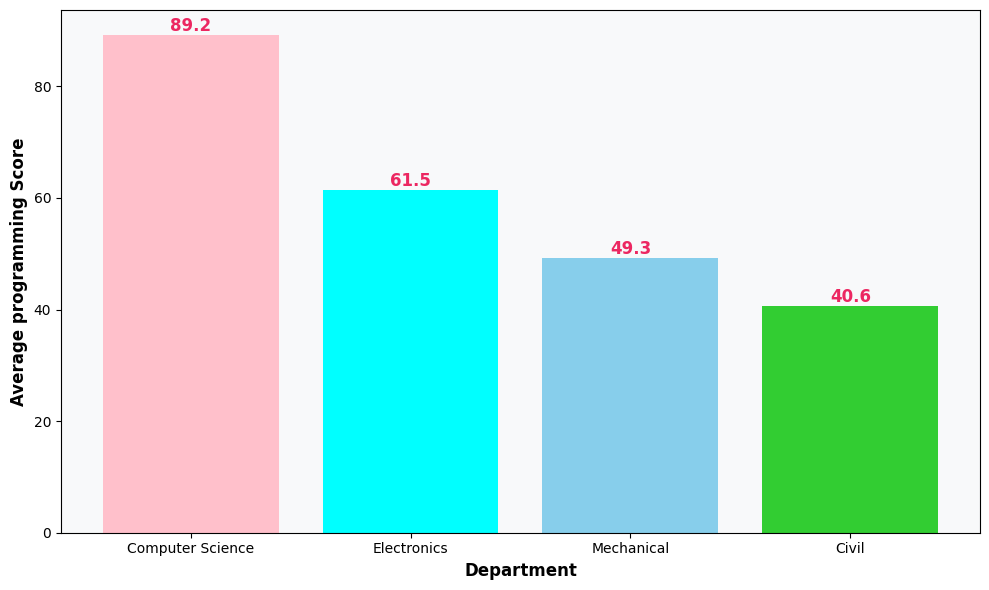

In [60]:
chart3_sql = """
    SELECT department, ROUND(AVG(programming_score), 2) AS avg_programming
    FROM students
    GROUP BY department
    ORDER BY avg_programming DESC
"""

chart3_data = pd.read_sql_query(chart3_sql, conn)


fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#FFC0CB', '#00FFFF', '#87CEEB', '#32CD32']

bars = ax.bar(
    chart3_data['department'],
    chart3_data['avg_programming'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.0
)

for bar in bars:
  height = bar.get_height()

  ax.text(
      bar.get_x() + bar.get_width()/ 2,
      height + 0.0,
      f'{height:.1f}',
      ha='center' , va='bottom',
      fontsize=12 , fontweight='bold',
      color='#EC2761'

  )


# X-axis label
ax.set_xlabel(
    'Department',
    fontsize=12,
    fontweight='bold'
)

# Y-axis label
ax.set_ylabel(
    'Average programming Score',
    fontsize=12,
    fontweight='bold'
)

# Background color
ax.set_facecolor('#F8F9FA')

# Grid lines
ax.grid(
    axis='y',
    linestyle='',
    alpha=0.5
)


# Adjust layout
plt.tight_layout()

# Show chart
plt.show()